# <span style="color: purple;">Lesson 9 - Introduction to Neural Networks</span>

**Developers:** Brian  |  **Reviewers:** Alina

---

## <span style="color: purple;">🎯 Learning Objectives</span>

By the end of this lesson, you will have:

- Defined a simple neural network in PyTorch
- Trained the network on a real dataset
- Monitored how training loss changes over time
- Explained what layers and neurons do in a model

<div class="alert alert-info">

**How it works:** Click the ▶ button on the top left of each code cell, top to bottom. Read the explanation after you see the output. That's it!

</div>

In [41]:
# ─────────────────────────────────────────────────────────────
# Setup cell — run this first, then you can ignore it
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm

print("✓ Ready to go!")

✓ Ready to go!


---

## <span style="color: purple;">🌍 Why Neural Networks Matter in Modern AI</span>

### Neural networks as the backbone

Many of today's best AI models are built from neural networks. Different models may have different architectures (such as CNNs, RNNs, Transformers), but they are all neural-network-based designs.

This is why learning neural networks is so important: once you understand them, you understand the foundation of AI and machine learning.

### Models that you already interact with

A lot of everyday AI tools are powered by neural networks:

- Chatbots and AI assistants
- Translation apps
- Voice assistants (speech recognition)
- Face unlock on phones
- Recommendation systems (YouTube, Netflix, Spotify)
- Image generation and editing tools

<div class="alert alert-info">

**Key Idea:** Even though these models do very different things, the fundamental building blocks are just neural networks learning patterns from data.

</div>

### Why this matters?

If you learn neural networks, you are not just learning one topic. You are learning the main idea behind much of today's AI technology.

That helps you to:

1. Understand how modern AI smodels are built - it's not magic!
2. Understand why they are powerful and their applications.
3. Ask better questions about fairness, trust, and safety related to AI usage.

---

## <span style="color: purple;">🧠 Where Do Neural Networks Come From?</span>

Neural networks are inspired by biology—specifically, by how your brain works. Before we build a mathematical model, let's learn about real neurons in the brain.

### What is a Biological Neuron?

Your brain contains roughly 86 billion neurons. Each one is a cell that receives electrical signals from other neurons, processes them, and sends signals onward. Neurons are the basic units of thought, memory, and movement.

A biological neuron has three main parts:

<div class="alert alert-success">

**Biological neuron** - A cell in the brain that receives electrical signals via dendrites, integrates them in the soma, and transmits signals along the axon.

**Artificial neuron / Neuron** - A mathematical function that takes inputs, multiplies them by weights, adds a bias, and applies an activation rule to produce an output.

</div>

---

## <span style="color: purple;">➕ The Maths: How One Artificial Neuron Works</span>
Now we have seen how the biological neurons inspired the artifical neuron, we can explore how the maths further. As shown above, a single artificial neuron performs 3 steps:

**Step 1: Multiply each input by its weight.** Weights represent the strength of each connection—just like synapses in the brain can be strong or weak.

**Step 2: Sum them all with a bias.** The bias is a small starting value, like the baseline signal level in a real neuron.

**Step 3: Apply an activation function.** This is like a neuron deciding whether to "fire." If the signal is strong enough, it passes through; otherwise it stays quiet.

In symbols:

$$y = (w_1x_1 + w_2x_2 + w_3x_3) + b$$

$$z_{\text{output}} = f_{act}(y)$$

A common activation function knwon as ReLU (Rectified Linear Unit) is a simple rule:

$$\mathrm{ReLU}(y)=\begin{cases}z & \text{if } y>0 \\ 0 & \text{if } y\le 0\end{cases}$$

This means: if the weighted sum is positive, pass it through; if it's zero or negative, output zero (the neuron is "silent").

### Understanding Weights

Think of weights as **importance sliders**:

- **Weight is large e.g. $w_1 >> 0$:** <br> input $x_1$ strongly influences the neuron's decision
- **Weight near zero e.g. $w_2\approx0$:** <br> input $x_2$ barely matters
- **Negative weight e.g. $w_3<0$:** <br> input $x_3$ pushes the decision the opposite way relative to $x_1$

<div class="alert alert-info">

❗ **During training, the network learns and adjusts the weights to make better predictions.** After thousands of adjustments, the weights learn patterns in the data.

</div>

<div class="alert alert-success">

**Weight** - A value that controls the strength of a connection. <br>
**Bias** - An extra value added to the sum to help shift the activation point.

</div>

### Visualising an Artificial Neuron

Below is a diagram of how a single artificial neuron works. Compare it to the biological neuron above—the structure mirrors biology, but everything is numbers:

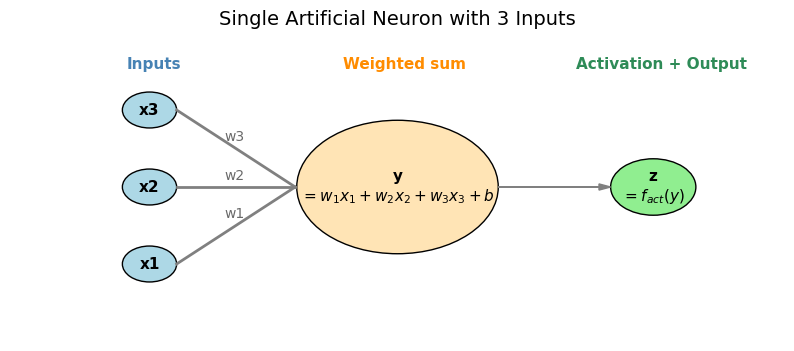

In [2]:
plt.figure(figsize=(10, 4))
ax = plt.gca()
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

# Input nodes
input_y = [1.5, 3.0, 4.5]
for i, y in enumerate(input_y, start=1):
    circle = plt.Circle((1.8, y), 0.35, color='lightblue', ec='black')
    ax.add_patch(circle)
    plt.text(1.8, y, f'x{i}', ha='center', va='center', fontsize=11, weight='bold')

# Single neuron node
neuron = plt.Circle((5.0, 3.0), 1.3, color='moccasin', ec='black')
ax.add_patch(neuron)
plt.text(5.0, 3.0, 'y\n$=w_1x_1 + w_2x_2 + w_3x_3 + b$', ha='center', va='center', fontsize=11, weight='bold')

# Output node
out = plt.Circle((8.3, 3.0), 0.55, color='lightgreen', ec='black')
ax.add_patch(out)
plt.text(8.3, 3.0, 'z\n$=f_{act}(y)$', ha='center', va='center', fontsize=11, weight='bold')

# Connections with labels
weights = ['w1', 'w2', 'w3']
for y, w in zip(input_y, weights):
    plt.plot([2.15, 3.68], [y, 3.0], color='gray', linewidth=2)
    mid_x = (2.15 + 3.68) / 2
    mid_y = (y + 3.0) / 2
    plt.text(mid_x - 0.15, mid_y + 0.15, w, fontsize=10, color='dimgray')

# plt.plot([6.22, 7.5], [3.0, 3.0], color='gray', linewidth=2)
plt.arrow(6.3, 3.0, 1.3, 0.0, head_width=0.12, head_length=0.15, fc='gray', ec='gray')

plt.text(1.5, 5.3, 'Inputs', fontsize=11, color='steelblue', weight='bold')
plt.text(4.3, 5.3, 'Weighted sum', fontsize=11, color='darkorange', weight='bold')
plt.text(7.3, 5.3, 'Activation + Output', fontsize=11, color='seagreen', weight='bold')
plt.title('Single Artificial Neuron with 3 Inputs', fontsize=14)

plt.show()

<div class="alert alert-info">

Run the code below to see an example of how numbers are processed in an artificial neuron.

</div>

In [ ]:
### Worked Example: Computing One Neuron by Hand

# Let's compute the output of a single neuron with concrete numbers:

# A tiny worked example with simple numbers
x1, x2, x3 = 2, 1, 3
w1, w2, w3 = 0.5, -0.2, 0.4
b = 0.1

z = (w1 * x1) + (w2 * x2) + (w3 * x3) + b
output = max(0, z)  # ReLU

print(f"Inputs:  x1={x1}, x2={x2}, x3={x3}")
print(f"Weights: w1={w1}, w2={w2}, w3={w3}")
print(f"Bias:    b={b}")
print()
print(f"Step 1: z = ({w1}×{x1}) + ({w2}×{x2}) + ({w3}×{x3}) + {b}")
print(f"Step 2: z = {z:.2f}")
print(f"Step 3: ReLU({z:.2f}) = max(0, {z:.2f}) = {output:.2f}")
print()
print(f"Result: This neuron outputs {output:.2f}")

Inputs:  x1=2, x2=1, x3=3
Weights: w1=0.5, w2=-0.2, w3=0.4
Bias:    b=0.1

Step 1: z = (0.5×2) + (-0.2×1) + (0.4×3) + 0.1
Step 2: z = 2.10
Step 3: ReLU(2.10) = max(0, 2.10) = 2.10

Result: This neuron outputs 2.10


---

## <span style="color: purple;">🚀 From One Neuron to a Network</span>

### The Single Layer Perceptron (SLP)

The single neuron we just visualised is actually a famous type of model called a **Single Layer Perceptron**. For a long time, this was the only kind of neural network scientists used. 

While it's very useful for simple decisions (like binary classification), one neuron is limited—it can only learn patterns that can be separated by a simple straight line.

### Stacking Neurons: The Hidden Layer

To solve the complex problems we see in modern AI, we need more "brain power." We get this by **stacking** many neurons together into **layers**.

When we connect a layer of neurons between our inputs and our output, we call it a **Hidden Layer**. By increasing the number of hidden layers, "Deep" Neural Networks are created and characterised by the following aspects:

- **Complexity:** By having many neurons working together, the network can learn curves, shapes, and complicated patterns that a single neuron would miss.
- **The "Network":** Everything is interconnected—every input goes to every hidden neuron, and every hidden neuron contributes to the final result.

<div class="alert alert-info">

**Run the next cell** to visualise how these neurons are combined to form a **single hidden layer neural network**.

</div>

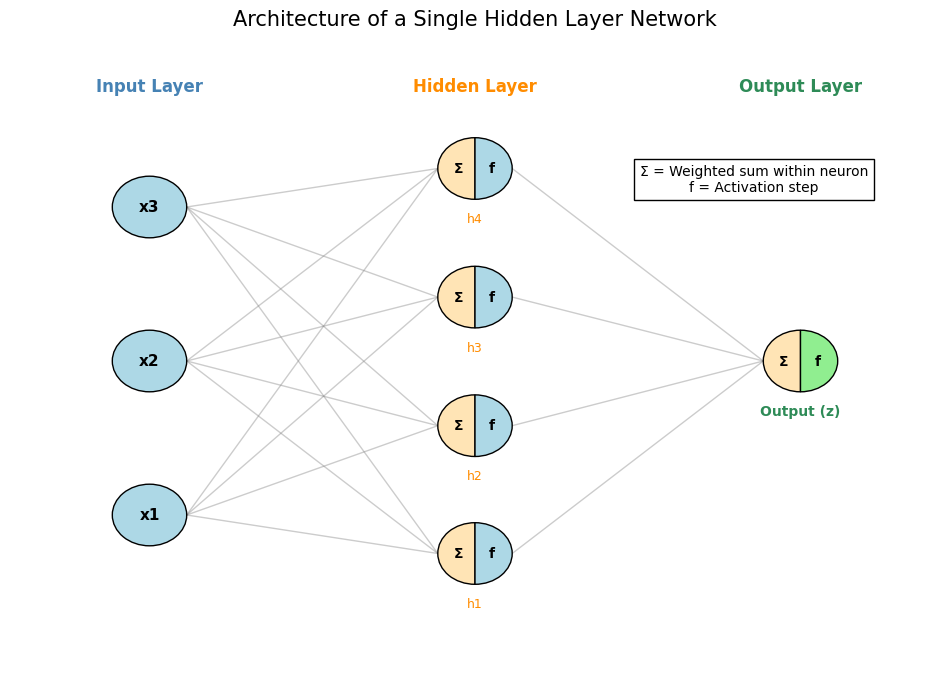

In [37]:
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge

plt.figure(figsize=(12, 8))
ax = plt.gca()
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')

# Node positions
input_y = [2.0, 4.0, 6.0]
hidden_y = [1.5, 3.16, 4.83, 6.5]
output_y = [4.0]

# Layer X positions
x_in = 1.5
x_hid = 5.0
x_out = 8.5
r = 0.4 # radius

# Draw connections
for iy in input_y:
    for hy in hidden_y:
        plt.plot([x_in+r, x_hid-r], [iy, hy], color='gray', linewidth=1, alpha=0.4, zorder=1)

for hy in hidden_y:
    for oy in output_y:
        plt.plot([x_hid+r, x_out-r], [hy, oy], color='gray', linewidth=1, alpha=0.4, zorder=1)

# Input nodes (Single circles)
for i, y in enumerate(input_y, start=1):
    circle = plt.Circle((x_in, y), r, color='lightblue', ec='black', zorder=3)
    ax.add_patch(circle)
    plt.text(x_in, y, f'x{i}', ha='center', va='center', fontsize=11, weight='bold', zorder=4)

# Hidden neurons (Split circles)
for i, y in enumerate(hidden_y, start=1):
    # Left half: Summation
    w1 = Wedge((x_hid, y), r, 90, 270, color='moccasin', ec='black', zorder=3)
    ax.add_patch(w1)
    # Right half: Activation
    w2 = Wedge((x_hid, y), r, 270, 90, color='lightblue', ec='black', zorder=3)
    ax.add_patch(w2)
    
    plt.text(x_hid-r/2.2, y, 'Σ', ha='center', va='center', fontsize=10, weight='bold', zorder=4)
    plt.text(x_hid+r/2.2, y, 'f', ha='center', va='center', fontsize=10, weight='bold', zorder=4)
    plt.text(x_hid, y-r-0.3, f'h{i}', ha='center', fontsize=9, color='darkorange')

# Output neuron (Split circle - restored)
y_o = output_y[0]
w_out1 = Wedge((x_out, y_o), r, 90, 270, color='moccasin', ec='black', zorder=3)
ax.add_patch(w_out1)
w_out2 = Wedge((x_out, y_o), r, 270, 90, color='lightgreen', ec='black', zorder=3)
ax.add_patch(w_out2)
plt.text(x_out-r/2.2, y_o, 'Σ', ha='center', va='center', fontsize=10, weight='bold', zorder=4)
plt.text(x_out+r/2.2, y_o, 'f', ha='center', va='center', fontsize=10, weight='bold', zorder=4)
plt.text(x_out, y_o-r-0.3, 'Output (z)', ha='center', fontsize=10, color='seagreen', weight='bold')

# Legend/Key
plt.text(8, 6.2, 'Σ = Weighted sum within neuron\nf = Activation step', 
         ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=1, edgecolor='black'))

# Layer labels
plt.text(x_in, 7.5, 'Input Layer', ha='center', fontsize=12, color='steelblue', weight='bold')
plt.text(x_hid, 7.5, 'Hidden Layer', ha='center', fontsize=12, color='darkorange', weight='bold')
plt.text(x_out, 7.5, 'Output Layer', ha='center', fontsize=12, color='seagreen', weight='bold')

plt.title('Architecture of a Single Hidden Layer Network', fontsize=15, pad=20)
plt.show()


### Deep Learning: *Many* Hidden Layer

Deep Neural Network (DNN) is essentially a more advanced version of the "brain-like" models we've been discussing. While a simple model might have one or two layers of "neurons," a Deep network stacks many of them on top of each other. 

A model with many hidden layers can have millions and billions of parameters (weights and biases from each artificial neuron). It has the potential to understand incredibly subtle patterns, but because there are so many "settings" to optimise,  it needs a vast amount of data to figure out the perfect setting for each one.

Just to put things into persepective, the first ChatGPT model released in 2022 had 175 billion parameters, where our single hidden layer model defined above has only 21 parameters.

<div class="alert alert-success">

**Deep Neural Network:** "Deep" refers to a neural network with many hidden layers stacked on top of one another

</div>

---
## <span style="color: purple;">📚 How a Network Learns: The Role of Data</span>

In traditional computer programming, we write down a set of explicit rules. However, for complex real-world tasks, there are often too many subtle rules to write by hand. 

**Neural Networks** solve this by learning from **Data**. Instead of us giving the network rules, we show it thousands of examples. The network then discovers the underlying patterns itself by studying the relationship between inputs and outputs.

### Training Data and Targets

Learning begins with a **Training Dataset**. This consists of:

*   **Features (Inputs):** The data the model uses to make a guess (e.g., iris chemistry).
*   **Labels (Targets):** The correct answers the model is trying to reach (e.g., the iris type).

### The Loss Function: Measuring Success

To improve, the network needs to know how well it is doing. This is where the **Loss Function** comes in. 

The **Loss Function** tells the model how close its output is to the targets. A high loss means the model is making bad guesses; a low loss means it is very close to the truth.

Training is the process of automatically adjusting the **weights** to **make this loss as small as possible**. 

<div class="alert alert-success">

**Loss Function / Loss** - A mathematical formula that measures how close the model's output is to the targets. The goal of training is to minimize this value.

</div>

---

## <span style="color: purple;">Step 1 - Load and prepare the data</span>

We need to prepare the data before training. We will:

- Load the iris dataset
- Split it into training and test sets
- Scale the features so they are on similar ranges
- Convert everything into PyTorch tensors

<div class="alert alert-info">

**Run the following cells** to load the data and set up two models - a **Single Layer Perceptron** and a **Single Hidden Layer Network**.

</div>

In [47]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# DataLoader for mini-batches
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f"Training samples: {len(X_train_tensor)}")
print(f"Test samples: {len(X_test_tensor)}")
print("✓ Data prepared")

Training samples: 120
Test samples: 30
✓ Data prepared


The dataset is now ready. We have separated training and test data, and scaled features so the network can learn more smoothly.

Next, we will define our first neural network.

In [48]:
# Model 1: Single Layer Perceptron (No hidden layer)
class SLP(nn.Module):
    def __init__(self, input_size=4, num_classes=3):
        super().__init__()
        self.network = nn.Linear(input_size, num_classes)

    def forward(self, x):
        return self.network(x)

# Model 2: Hidden Layer Network (One hidden layer)
class SimpleNet(nn.Module):
    def __init__(self, input_size=4, hidden_size=16, num_classes=3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        return self.network(x)

slp_model = SLP()
deep_model = SimpleNet()

# Capture initial weights before training
import copy
slp_init_state = copy.deepcopy(slp_model.state_dict())
deep_init_state = copy.deepcopy(deep_model.state_dict())

print("✓ Two models defined and initial weights captured.")

✓ Two models defined and initial weights captured.


The model is now set up and ready to learn. We also defined:

- A **loss function** to measure error
- An **optimizer** to update model weights

Now we can train and track the loss values.

<div class="alert alert-success">

**Training** - The iterative process of adjusting model weights to minimize the loss function and get the model outputs as close to targets as possible.

**Loss Function** - A mathematical formula that measures how far the model's prediction is from the target.

**Optimiser** - The algorithm that adjusts weights and biases to minimise loss.

</div>

---

## <span style="color: purple;">Step 3 - Train the model and monitor loss</span>

As training runs, we record the loss after each epoch. If learning is working, loss should usually go down over time.

<div class="alert alert-info">

**Run the following cells** to train the model by adjusting the weights and biases of the models.

</div>

In [50]:
epochs = 100
learning_rate = 0.01

def train_model(model, loader):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = []
    
    for epoch in range(epochs):
        running_loss = 0.0
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        history.append(running_loss / len(loader))
    return history

print("Training SLP...")
slp_history = train_model(slp_model, train_loader)

print("Training Deep Model...")
deep_history = train_model(deep_model, train_loader)

print("✓ Both models trained")

Training SLP...
Training Deep Model...
✓ Both models trained


Great, the model has trained. Next, let's visualise the loss to see the learning pattern clearly.

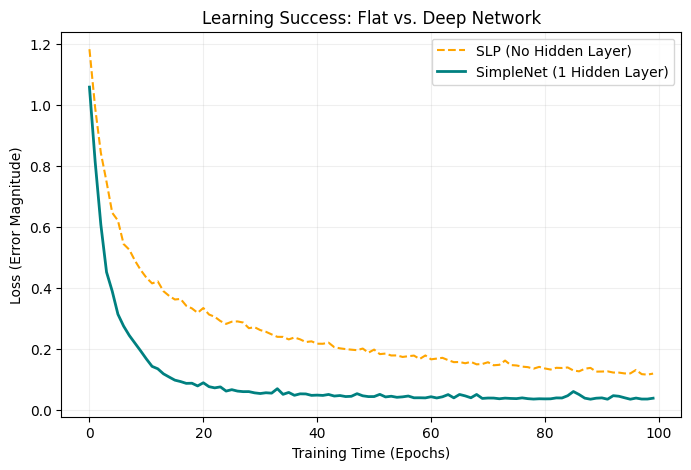

The chart shows how error (loss) decreases as the models learn.


In [51]:
plt.figure(figsize=(8, 5))
plt.plot(slp_history, label="SLP (No Hidden Layer)", color="orange", linestyle="--")
plt.plot(deep_history, label="SimpleNet (1 Hidden Layer)", color="teal", linewidth=2)
plt.title("Learning Success: Flat vs. Deep Network")
plt.xlabel("Training Time (Epochs)")
plt.ylabel("Loss (Error Magnitude)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("The chart shows how error (loss) decreases as the models learn.")

<div class="alert alert-info">

If the value of the loss function line goes down, your network is usually learning useful patterns. If it stays flat or jumps wildly, the model settings may need adjusting.

</div>

---

## <span style="color: purple;">Step 4 - Check test accuracy</span>

Now we test the model on data it did not see during training.

In [46]:
def get_accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        predictions = torch.argmax(logits, dim=1)
        return (predictions == y).float().mean().item()

slp_acc = get_accuracy(slp_model, X_test_tensor, y_test_tensor)
deep_acc = get_accuracy(deep_model, X_test_tensor, y_test_tensor)

print(f"SLP (Flat) Accuracy: {slp_acc * 100:.1f}%")
print(f"SimpleNet (Deep) Accuracy: {deep_acc * 100:.1f}%")

SLP (Flat) Accuracy: 93.3%
SimpleNet (Deep) Accuracy: 96.7%


<div class="alert alert-info">

This final score shows how the **neural network is able to better classify new data** compared to the single layer perceptron, this is due to **increased complexity** of the model!

</div>

---

## <span style="color: purple;">✅ Summary</span>

In this lesson, you explored how biological inspiration led to the creation of **Artificial Neural Networks**. Here is a summary of our Iris classification experiment:

1.  **Architecture Matters**: We compared a **Single Layer Perceptron (SLP)** with a **Deep Network**. We found that adding a **Hidden Layer** allows the network to learn non-linear patterns, leading to higher performance.
2.  **The Learning Core**: We defined the **Loss Function** (how the model measures its own mistakes) and the **Optimizer** (the math engine that drives weight adjustments).
3.  **Visualization**: We used **Graphviz** to see into the "brain" of the network, tracing how random weights at instantiation transform into structured values that solve the Iris task.

| Key term | Meaning |
|---|---|
| SLP | A basic network with no hidden layers (only Input -> Output) |
| Deep Network | A network with one or more hidden layers between Input and Output |
| Hidden Layer | The internal "thinking" layer that filters and extracts features |
| Loss Function | Measures the gap between predictions and targets |
| Optimizer | The algorithm that updates the weights based on the loss |
| Weights | The importance given to each input connection |
| Biases | The baseline offset added to a neuron's weighted sum |


---

## <span style="color: purple;">🚀 Challenge</span>

Change one model setting and observe what happens to the loss curve and test accuracy.

Try one of these:

- Increase `hidden_size` from 16 to 32
- Change `epochs` from 60 to 100
- Lower learning rate from `0.01` to `0.001`

In [57]:
# ▼▼▼▼▼▼▼▼▼▼▼▼▼▼  CHANGE THIS  ▼▼▼▼▼▼▼▼▼▼▼▼▼▼
test_hidden_size = 32  # ← try 8, 16, 32
test_learning_rate = 0.01  # ← try 0.001
test_epochs = 60  # ← try 100
# ▲▲▲▲▲▲▲▲▲▲▲▲▲▲  CHANGE THIS  ▲▲▲▲▲▲▲▲▲▲▲▲▲▲

challenge_model = SimpleNet(hidden_size=test_hidden_size)
challenge_criterion = nn.CrossEntropyLoss()
challenge_optimizer = torch.optim.Adam(challenge_model.parameters(), lr=test_learning_rate)

challenge_losses = []
for epoch in range(test_epochs):
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        challenge_optimizer.zero_grad()
        outputs = challenge_model(batch_X)
        loss = challenge_criterion(outputs, batch_y)
        loss.backward()
        challenge_optimizer.step()
        running_loss += loss.item()
    challenge_losses.append(running_loss / len(train_loader))

challenge_model.eval()
with torch.no_grad():
    challenge_logits = challenge_model(X_test_tensor)
    challenge_preds = torch.argmax(challenge_logits, dim=1)
    challenge_acc = (challenge_preds == y_test_tensor).float().mean().item()

print(f"Challenge accuracy: {challenge_acc * 100:.1f}%")
print(f"Challenge final loss: {challenge_losses[-1]:.4f}")
print("✓ Challenge complete")

Challenge accuracy: 96.7%
Challenge final loss: 0.0323
✓ Challenge complete


---

## <span style="color: purple;">🧠 Quiz</span>

Check your understanding of layers, neurons, and training.

In [59]:
from quiz import run_b09_quiz
run_b09_quiz()
print("✓ Quiz launched")

✓ Quiz launched
